# 1 — Exploratory Data Analysis

Goals:
- Load and inspect the NIFTY-50 dataset
- Check data quality (missing values, date coverage)
- Visualize price trends, volume, and sector composition
- Correlation analysis across stocks

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.preprocess import load_all_stocks, load_metadata, get_price_panel

sns.set_style('whitegrid')
%matplotlib inline

## 1.1 Load Data

In [2]:
stocks = load_all_stocks()
meta = load_metadata()

print(f'Loaded {len(stocks)} stocks')
print(f'Date range example (TCS): {stocks["TCS"].index.min()} → {stocks["TCS"].index.max()}')
meta.head(10)

Loaded 49 stocks
Date range example (TCS): 2004-08-25 00:00:00 → 2021-04-30 00:00:00


,Company_Name,Industry
Symbol,,
ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
ASIANPAINT,Asian Paints Ltd.,CONSUMER GOODS
AXISBANK,Axis Bank Ltd.,FINANCIAL SERVICES
BAJAJ-AUTO,Bajaj Auto Ltd.,AUTOMOBILE
BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES
BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES
BHARTIARTL,Bharti Airtel Ltd.,TELECOM
BPCL,Bharat Petroleum Corporation Ltd.,ENERGY
BRITANNIA,Britannia Industries Ltd.,CONSUMER GOODS


## 1.2 Data Quality Check

In [3]:
# Row counts and date coverage per stock
summary = []
for sym, df in stocks.items():
    summary.append({
        'symbol': sym,
        'rows': len(df),
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_close': df['Close'].isna().sum(),
        'missing_volume': df['Volume'].isna().sum() if 'Volume' in df.columns else -1,
    })

quality = pd.DataFrame(summary).set_index('symbol').sort_values('rows')
print(f'Min rows: {quality["rows"].min()}  |  Max rows: {quality["rows"].max()}')
quality.head(10)

Min rows: 2598  |  Max rows: 5306


,rows,start,end,missing_close,missing_volume
symbol,,,,,
COALINDIA,2598,2010-11-04,2021-04-30,0,0
NESTLEIND,2806,2010-01-08,2021-04-30,0,0
BAJAJFINSV,3201,2008-05-26,2021-04-30,0,0
BAJAJ-AUTO,3202,2008-05-26,2021-04-30,0,0
ADANIPORTS,3322,2007-11-27,2021-04-30,0,0
POWERGRID,3359,2007-10-05,2021-04-30,0,0
TECHM,3635,2006-08-28,2021-04-30,0,0
JSWSTEEL,3994,2005-03-23,2021-04-30,0,0
NTPC,4088,2004-11-05,2021-04-30,0,0


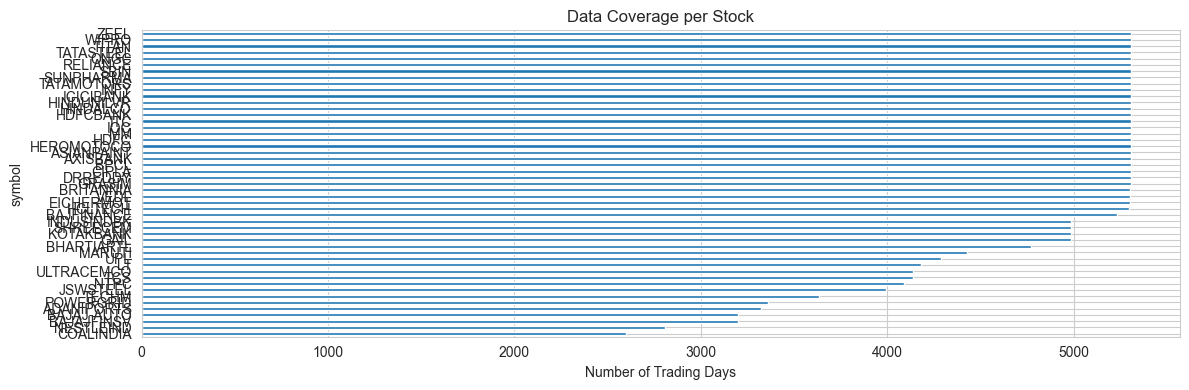

In [4]:
# Distribution of record counts
fig, ax = plt.subplots(figsize=(12, 4))
quality['rows'].sort_values().plot.barh(ax=ax)
ax.set_xlabel('Number of Trading Days')
ax.set_title('Data Coverage per Stock')
plt.tight_layout()
plt.show()

## 1.3 Sector Composition

In [5]:
sector_counts = meta['Industry'].value_counts()
fig = px.pie(values=sector_counts.values, names=sector_counts.index,
             title='NIFTY-50 Sector Composition')
fig.show()

## 1.4 Price Trends

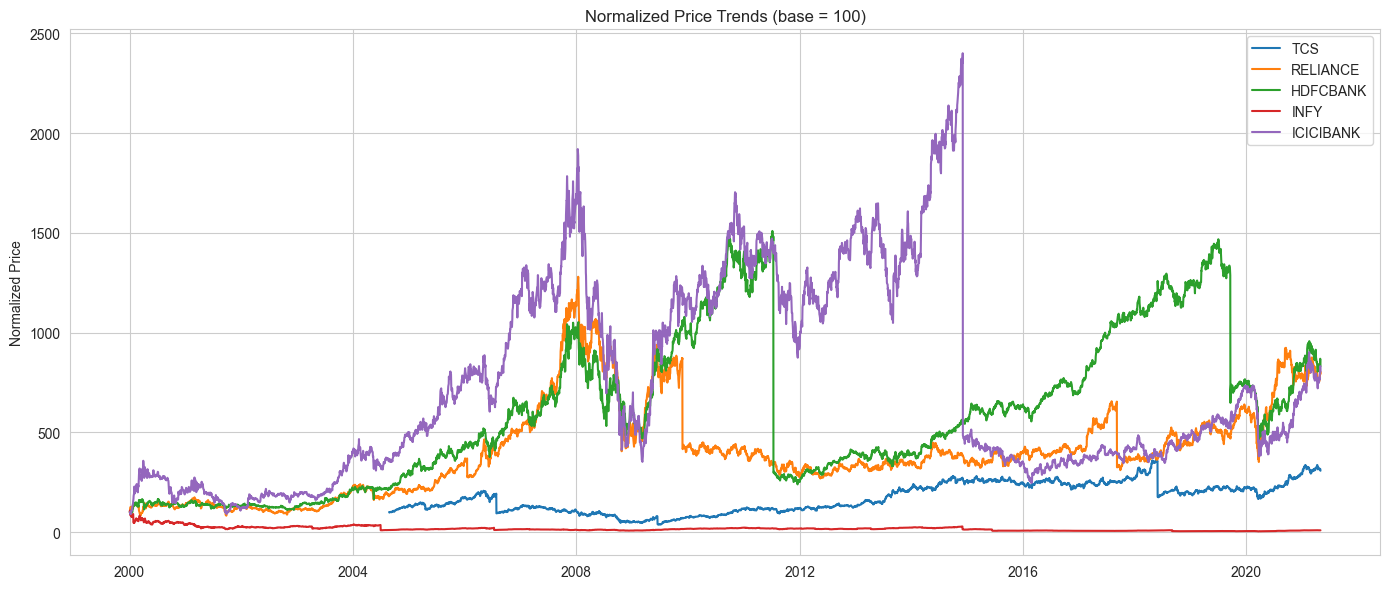

In [6]:
# Normalize prices to 100 at start for comparison
top5 = ['TCS', 'RELIANCE', 'HDFCBANK', 'INFY', 'ICICIBANK']

fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    close = stocks[sym]['Close']
    normalized = close / close.iloc[0] * 100
    ax.plot(normalized, label=sym)

ax.set_title('Normalized Price Trends (base = 100)')
ax.set_ylabel('Normalized Price')
ax.legend()
plt.tight_layout()
plt.show()

## 1.5 Volume Analysis

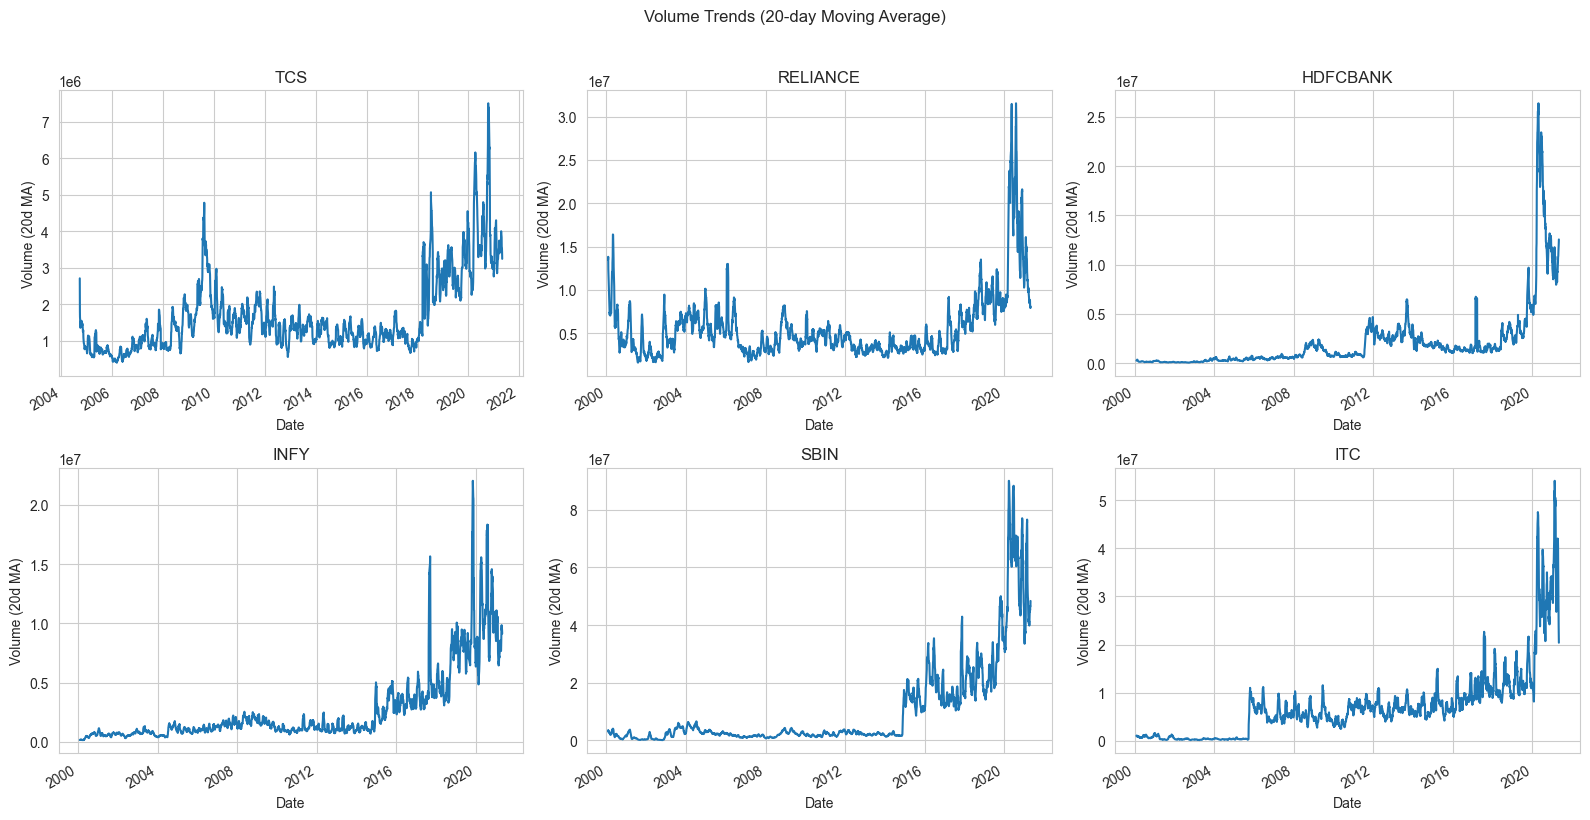

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, sym in zip(axes.flat, ['TCS', 'RELIANCE', 'HDFCBANK', 'INFY', 'SBIN', 'ITC']):
    df = stocks[sym]
    if 'Volume' in df.columns:
        df['Volume'].rolling(20).mean().plot(ax=ax, title=sym)
        ax.set_ylabel('Volume (20d MA)')
plt.suptitle('Volume Trends (20-day Moving Average)', y=1.02)
plt.tight_layout()
plt.show()

## 1.6 Returns Distribution

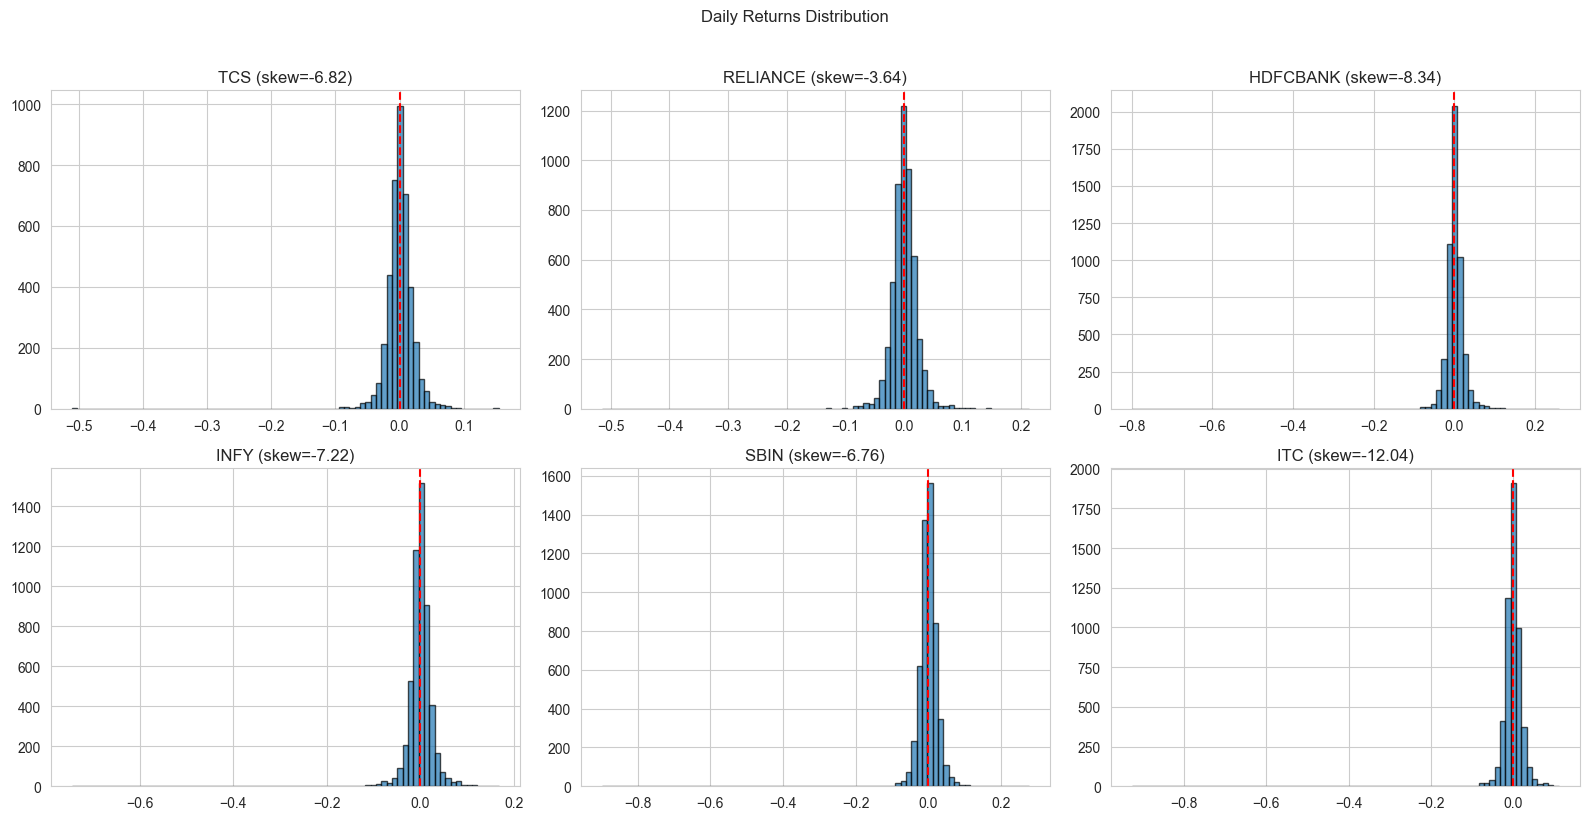

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, sym in zip(axes.flat, ['TCS', 'RELIANCE', 'HDFCBANK', 'INFY', 'SBIN', 'ITC']):
    returns = stocks[sym]['Close'].pct_change().dropna()
    ax.hist(returns, bins=80, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{sym} (skew={returns.skew():.2f})')
plt.suptitle('Daily Returns Distribution', y=1.02)
plt.tight_layout()
plt.show()

## 1.7 Correlation Heatmap

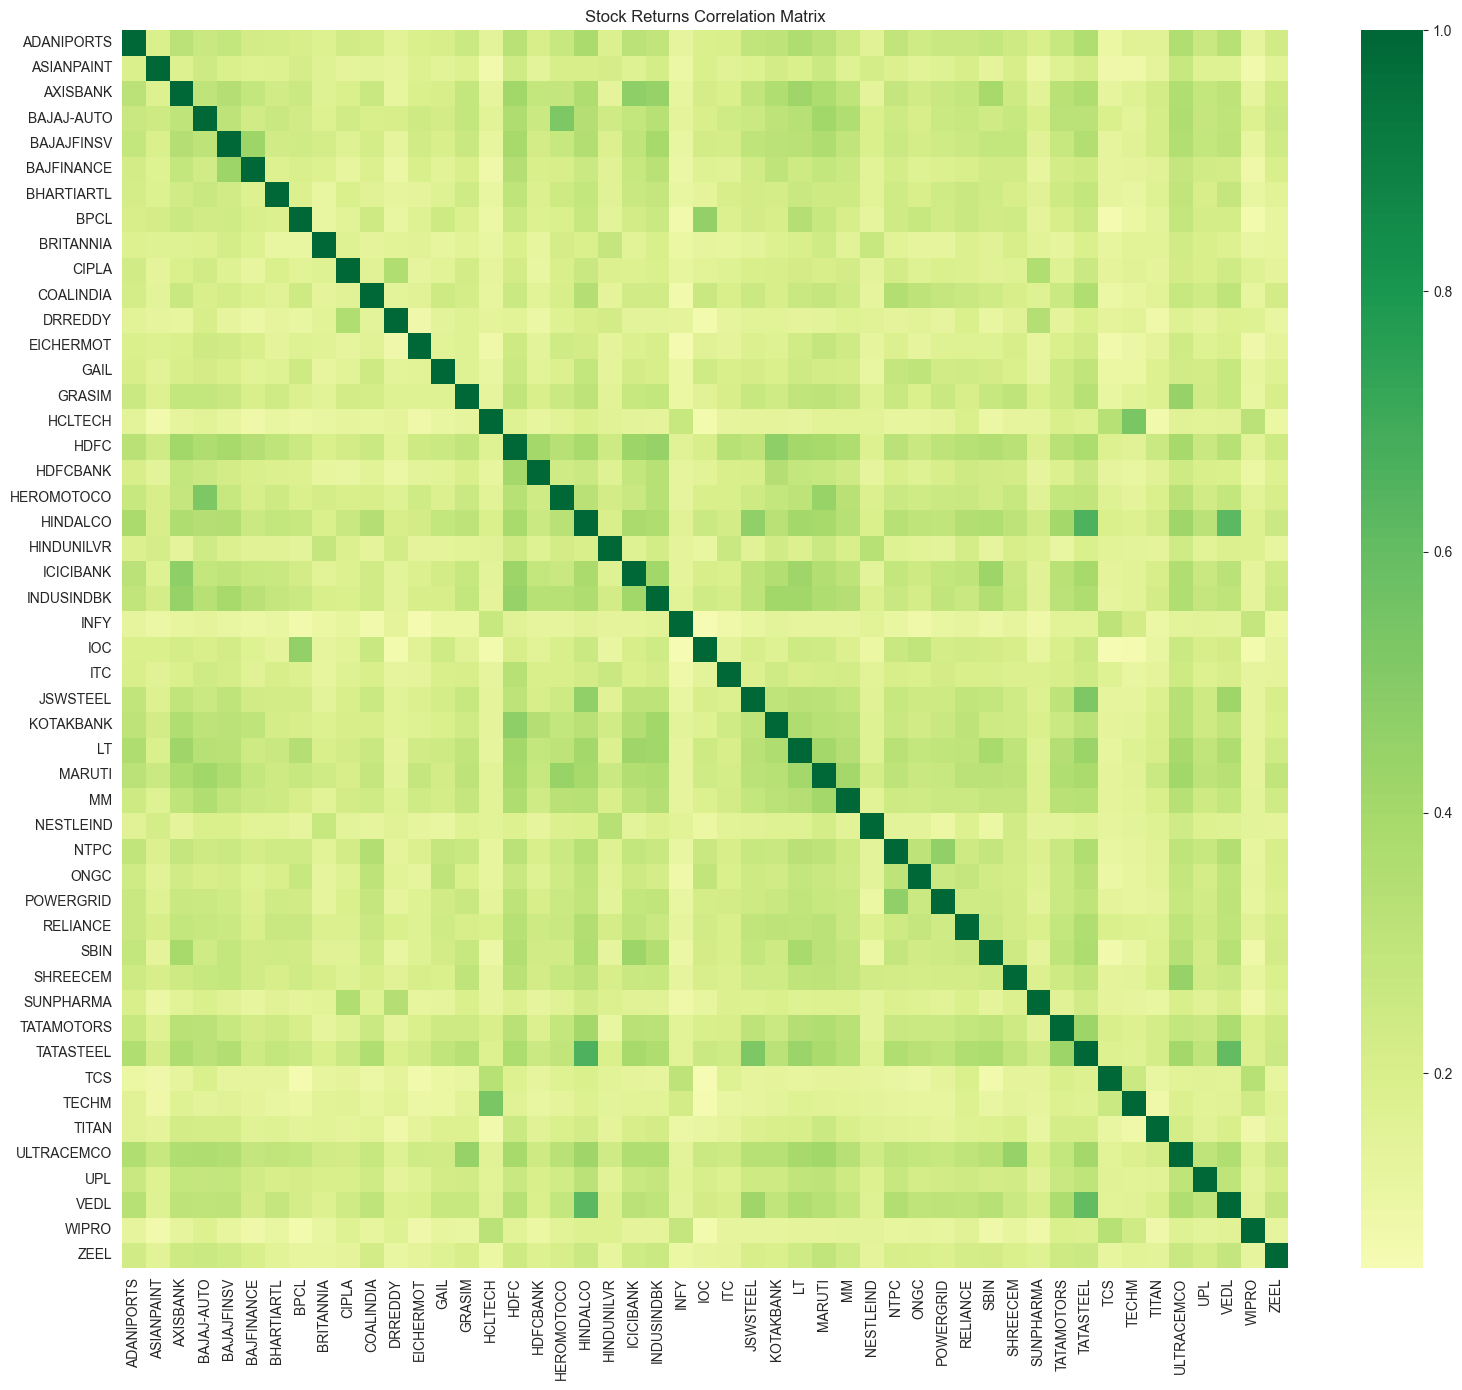

In [9]:
prices = get_price_panel()
returns = prices.pct_change().dropna()
corr = returns.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='RdYlGn', center=0, annot=False, ax=ax)
ax.set_title('Stock Returns Correlation Matrix')
plt.tight_layout()
plt.show()

## 1.8 Key Observations

- **Data spans ~2000–2021** with most stocks having 4000+ trading days
- **No critical missing data** — forward-fill handles small gaps
- **Returns are roughly symmetric** with slight negative skew for some stocks
- **Moderate positive correlation** across most stocks (market-wide factor)
- **Sector diversity**: Banking, IT, Energy, Consumer Goods, Pharma represented